In [1]:
# =============================================================================
#  HW3 — Dependencies (run this cell first in a fresh environment)
# ===========?==================================================================
# Installs: NumPy, Pandas and other libraries
# Comment out the line below after packages are installed if you prefer.

%pip install -i https://mirror-pypi.runflare.com/simple -U numpy pandas 

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://mirror-pypi.runflare.com/simple
Note: you may need to restart the kernel to use updated packages.


### Homework 3 — EDA on House Price India dataset

| | |
|:---|:---|
| **Course** | basic Data Mining |
| **Team Name** | Spark |
| **Submission** | This file `hw3.ipynb` with **Run All** outputs saved and PDF report. |
| **Full assignment text** | `HW3.pdf` |

**Data file** (put next to the notebook, or edit paths in the imports cell):

### Libraries

In [2]:

import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean, cityblock


df=pd.read_csv('./House Price India.csv')
# print("done!")
print(f"Number of rows: {df.shape[0]}, number of columns: {df.shape[1]}")
print(df.head())

/home/zahra/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Number of rows: 14619, number of columns: 22
           id  number of bedrooms  number of bathrooms  living area  lot area  \
0  6762810635                   4                 2.50         2920      4000   
1  6762810998                   5                 2.75         2910      9480   
2  6762812605                   4                 2.50         3310     42998   
3  6762812919                   3                 2.00         2710      4500   
4  6762813105                   3                 2.50         2600      4750   

   number of floors  waterfront present  number of views  \
0               1.5                   0                0   
1               1.5                   0                0   
2               2.0                   0                0   
3               1.5                   0                0   
4               1.0                   0                0   

   condition of the house  grade of the house  ...  Built Year  \
0                       5                

### 1. Data Steward

#### 1.1

In [3]:
print("Feature categories:\n")

feature_categories = {
    'id': 'Nominal',
    'number of bedrooms': 'Discrete _ Ratio-scaled',
    'number of bathrooms': 'Discrete_Ratio-scaled',
    'living area': 'Continuous_ratio-scaled',
    'lot area': 'Continuous_ratio-scaled',
    'number of floors': 'Discrete_ratio-scaled',
    'waterfront present': 'Binary_Asymmetric',
    'number of views': 'Discrete_ratio-scaled',
    'condition of the house': 'Ordinal',
    'grade of the house': 'Ordinal',
    'Area of the house(excluding basement)': 'Continuous_ratio-scaled',
    'Area of the basement': 'Continuous_ratio-scaled',
    'Built Year': 'Discrete_Interval-scaled',
    'Renovation Year': 'Discrete_Interval-scaled',
    'Postal Code': 'Nominal',
    'Lattitude': 'Continuous_Interval-scaled',
    'Longitude': 'Continuous_Interval-scaled',
    'living_area_renov': 'Continuous_ratio-scaled',
    'lot_area_renov': 'Continuous_ratio-scaled',
    'Number of schools nearby': 'Discrete_ratio-scaled',
    'Distance from the airport': 'Continuous_ratio-scaled',
    'Price': 'Continuous_ratio-scaled_ target'
}

for feature, ftype in feature_categories.items():
    print(f"{feature:<40} -> {ftype}")

Feature categories:

id                                       -> Nominal
number of bedrooms                       -> Discrete _ Ratio-scaled
number of bathrooms                      -> Discrete_Ratio-scaled
living area                              -> Continuous_ratio-scaled
lot area                                 -> Continuous_ratio-scaled
number of floors                         -> Discrete_ratio-scaled
waterfront present                       -> Binary_Asymmetric
number of views                          -> Discrete_ratio-scaled
condition of the house                   -> Ordinal
grade of the house                       -> Ordinal
Area of the house(excluding basement)    -> Continuous_ratio-scaled
Area of the basement                     -> Continuous_ratio-scaled
Built Year                               -> Discrete_Interval-scaled
Renovation Year                          -> Discrete_Interval-scaled
Postal Code                              -> Nominal
Lattitude                        

#### 1.2

In [4]:
print("Checking missing values...")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values exist.\n")

print("\nChecking duplicate data...")
print(f"Number of fully duplicated rows: {df.duplicated().sum()}")
print(f"Number of duplicated IDs: {df['id'].duplicated().sum()}")

if df.duplicated().sum() == 0:
    print("No duplicate data exists.")

Checking missing values...
No missing values exist.


Checking duplicate data...
Number of fully duplicated rows: 0
Number of duplicated IDs: 0
No duplicate data exists.


#### 1.3

In [5]:
print("Five-Number Summary:")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numeric_cols:
    numeric_cols.remove('id')

for col in numeric_cols:
    print(f"\n{col}:")
    print(f" Min:     {df[col].min()}")
    print(f" Q1:   {df[col].quantile(0.25)}")
    print(f" Median:  {df[col].median()}")
    print(f" Q3:   {df[col].quantile(0.75)}")
    print(f" Max:    {df[col].max()}")

Five-Number Summary:

number of bedrooms:
 Min:     1
 Q1:   3.0
 Median:  3.0
 Q3:   4.0
 Max:    33

number of bathrooms:
 Min:     0.5
 Q1:   1.75
 Median:  2.25
 Q3:   2.5
 Max:    8.0

living area:
 Min:     370
 Q1:   1440.0
 Median:  1930.0
 Q3:   2570.0
 Max:    13540

lot area:
 Min:     520
 Q1:   5010.5
 Median:  7620.0
 Q3:   10800.0
 Max:    1074218

number of floors:
 Min:     1.0
 Q1:   1.0
 Median:  1.5
 Q3:   2.0
 Max:    3.5

waterfront present:
 Min:     0
 Q1:   0.0
 Median:  0.0
 Q3:   0.0
 Max:    1

number of views:
 Min:     0
 Q1:   0.0
 Median:  0.0
 Q3:   0.0
 Max:    4

condition of the house:
 Min:     1
 Q1:   3.0
 Median:  3.0
 Q3:   4.0
 Max:    5

grade of the house:
 Min:     4
 Q1:   7.0
 Median:  7.0
 Q3:   8.0
 Max:    13

Area of the house(excluding basement):
 Min:     370
 Q1:   1200.0
 Median:  1580.0
 Q3:   2240.0
 Max:    9410

Area of the basement:
 Min:     0
 Q1:   0.0
 Median:  0.0
 Q3:   580.0
 Max:    4820

Built Year:
 Min:     1900
 Q1

#### 1.5

In [6]:
print("Removing 5 percent of the living area values:")

living = df['living area'].copy()

np.random.seed(42)
mask = np.random.rand(len(living)) < 0.05
living_missing = living.copy()
living_missing[mask] = np.nan
print(f"Number of removed data points: {living_missing.isnull().sum()}")

bins = pd.cut(living, bins=10, labels=False)


# Fill using the mean of each bin (Bin Mean)
print("\nMethod 1: Fill using the mean of each bin (Bin Mean)")
bin_means = living.groupby(bins).mean()
living_filled1 = living_missing.copy()

for i in range(len(living_missing)):
    if pd.isna(living_missing.iloc[i]):
        living_filled1.iloc[i] = bin_means[bins.iloc[i]]
print(f"Number of remaining missing values: {living_filled1.isnull().sum()}")



# Fill using the median of each bin (Bin Median)
print("\nMethod 2: Fill using the median of each bin (Bin Median)")
bin_medians = living.groupby(bins).median()
living_filled2 = living_missing.copy()

for i in range(len(living_missing)):
    if pd.isna(living_missing.iloc[i]):
        living_filled2.iloc[i] = bin_medians[bins.iloc[i]]
print(f"Number of remaining missing values: {living_filled2.isnull().sum()}")

# print("\ndone!")

Removing 5 percent of the living area values:
Number of removed data points: 729

Method 1: Fill using the mean of each bin (Bin Mean)
Number of remaining missing values: 0

Method 2: Fill using the median of each bin (Bin Median)
Number of remaining missing values: 0


#### 1.7

In [7]:
from scipy.spatial.distance import euclidean, cityblock

min_price_house = df.loc[df['Price'].idxmin()]
max_price_house = df.loc[df['Price'].idxmax()]

print("Two houses with the highest and lowest prices:")
print(f"House with the lowest price: {min_price_house['Price']} dolars")
print(f"House with the highest price: {max_price_house['Price']} dolars")
print(f"Price difference: {max_price_house['Price'] - min_price_house['Price']:,} dolars")

features = ['living area', 'lot area', 'number of bathrooms', 
            'number of floors', 'number of views', 'condition of the house',
            'grade of the house', 'Number of schools nearby', 
            'Distance from the airport', 'Lattitude', 'Longitude']

vec_min = min_price_house[features].values
vec_max = max_price_house[features].values

eucl_dist = euclidean(vec_min, vec_max)
man_dist = cityblock(vec_min, vec_max)

print(f"\nDistances between the two houses:")
print(f"Euclidean distance: {eucl_dist:.2f}")
print(f"Manhattan distance: {man_dist:.2f}")

Two houses with the highest and lowest prices:
House with the lowest price: 78000.0 dolars
House with the highest price: 7700000.0 dolars
Price difference: 7,622,000.0 dolars

Distances between the two houses:
Euclidean distance: 15928.29
Manhattan distance: 22550.70


### 2. Analyst

#### 2.1

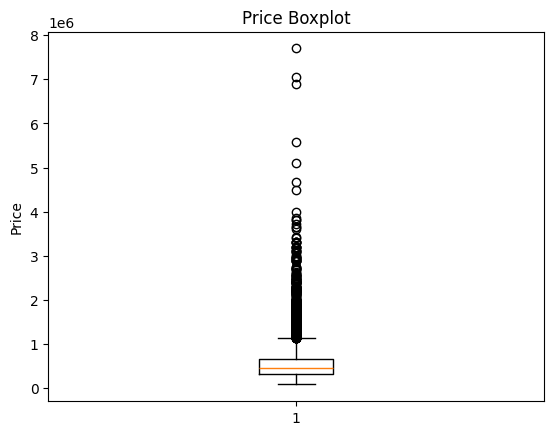

In [8]:
data = pd.read_csv("House Price India.csv")
plt.boxplot(data["Price"])
plt.title("Price Boxplot")
plt.ylabel("Price")
plt.show()


<!-- <div dir="rtl" style="text-align: right;">
ابتدا داده‌ها را با read_csv خواندیم.
سپس با استفاده از تابع boxplot matplotlib نمودار را برای متغیر price رسم کردیم تا پراکندگی و نقاط پرت آن را بررسی کنیم.
</div> -->

First, we read the data using `read_csv`.
Then, using Matplotlib's `boxplot` function, we drew a chart for the `Price` variable to examine its spread and outliers.



#### 2.2

In [9]:
print('Lowest Built Year is: ',data["Built Year"].min())
print('Highest Built Year is',data["Built Year"].max())

Lowest Built Year is:  1900
Highest Built Year is 2015


<!-- <div dir="rtl" style="text-align: right;">
کوچکترین و بزرگترین سال ساخت را به دست آوردیم و برای بازه بندی ۵ ساله با توجه به اختلاف min , max  تقسیم بر ۵، به ۲۳ bins برای نمایش هیستوگرام نیاز داریم 
</div> -->

We found the smallest and largest construction years, and for 5-year binning, based on the difference between min and max divided by 5, we need 23 bins to display the histogram.



Text(0.5, 1.0, 'Construction Periods by 5 Years')

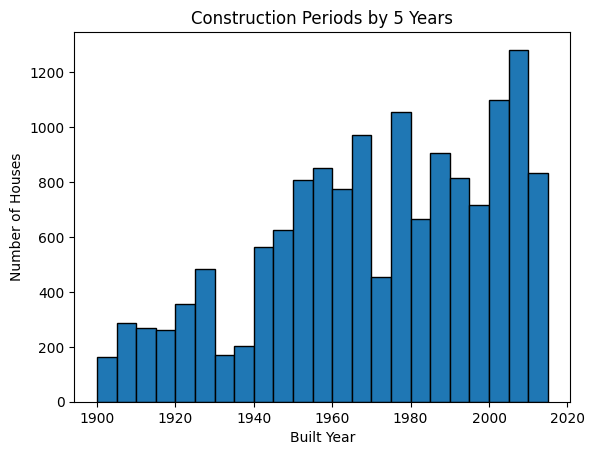

In [10]:
plt.hist(data["Built Year"], bins=23, edgecolor="black")
plt.xlabel("Built Year")
plt.ylabel("Number of Houses")
plt.title("Construction Periods by 5 Years")

<!-- <div dir="rtl" style="text-align: right;">
با استفاده از تابع hist matplotlib و تقسیم بندی ۵ ساله، نمودار را رسم می‌کنیم 
</div> -->
Using Matplotlib's `hist` function and 5-year binning, we draw the chart.


#### 2.3

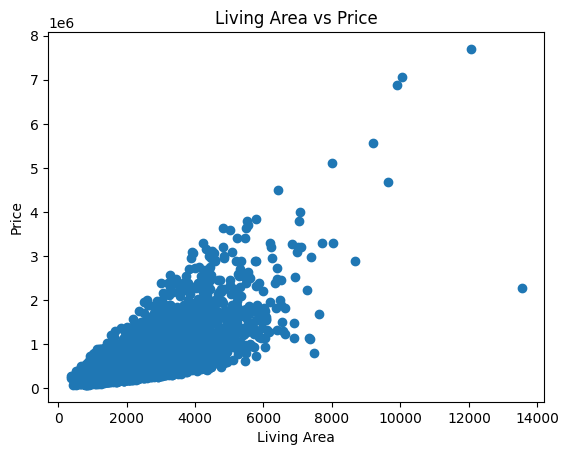

In [11]:
plt.scatter(data["living area"], data["Price"])
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.title("Living Area vs Price")
plt.show()

<!-- <div dir="rtl" style="text-align: right;">
با استقاده از تابع scatter matplotlib برای دو متغیر Price , Living area نمودار را رسم کردیم.
</div> -->
Using Matplotlib's `scatter` function, we plotted the chart for the two variables `Price` and `Living area`.


#### 2.4

In [12]:
print(data.select_dtypes(include=['int64', 'float64']).columns)

Index(['id', 'number of bedrooms', 'number of bathrooms', 'living area',
       'lot area', 'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')


<!-- <div dir="rtl" style="text-align: right;">
ابتدا متغیر های عددی را شناسایی کردیم و مشاهده شد که تمام متغیر ها در این دیتاست عددی 
هستند 
</div> -->
First, we identified the numerical variables, and it was observed that all variables in this dataset are numerical.


In [13]:
corr_matrix =data.corr()
print(corr_matrix)

                                             id  number of bedrooms  \
id                                     1.000000           -0.328899   
number of bedrooms                    -0.328899            1.000000   
number of bathrooms                   -0.516909            0.509783   
living area                           -0.648058            0.570441   
lot area                              -0.100298            0.034438   
number of floors                      -0.312237            0.177208   
waterfront present                    -0.112959           -0.006247   
number of views                       -0.292699            0.078157   
condition of the house                -0.044797            0.026326   
grade of the house                    -0.673374            0.352795   
Area of the house(excluding basement) -0.565021            0.473482   
Area of the basement                  -0.290839            0.300367   
Built Year                            -0.068857            0.153184   
Renova

<!-- <div dir="rtl" style="text-align: right;">
ماتریس همبستگی را به دست می‌آوریم ( برای همه متغیر ها چون همه مقدار عددی دارند) و آن را نمایش می‌دهیم.</div> -->
We compute the correlation matrix (for all variables since all of them are numeric) and display it.


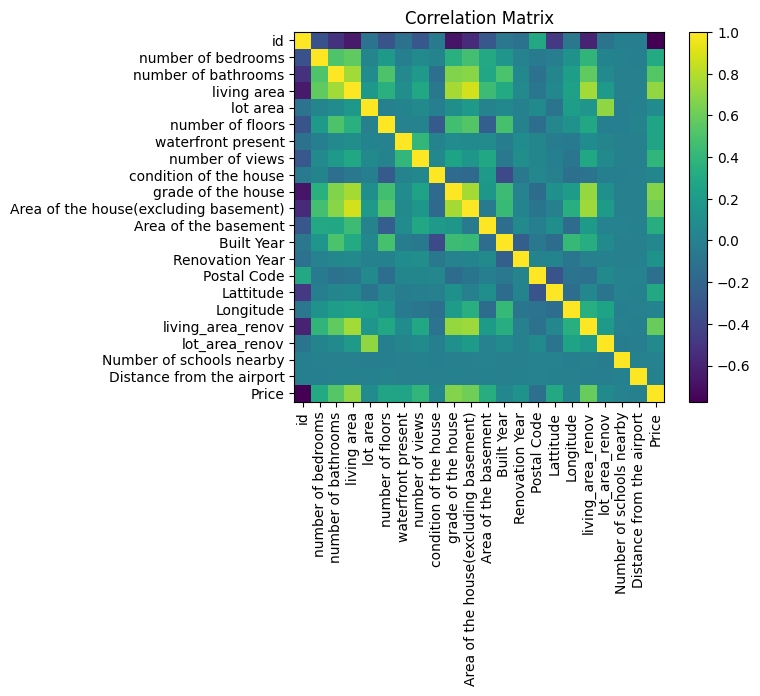

In [14]:
plt.imshow(corr_matrix)

plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.show()


<!-- <div dir="rtl" style="text-align: right;">
حالا با استفاده از تابع imshow matplotlib، ماتریس همبستگی را به صورت یک تصویر Heatmap نمایش می‌دهیم.
</div> -->
Now, using Matplotlib’s `imshow` function, we display the correlation matrix as a Heatmap image.


#### 2.6

In [15]:
print('Minimum house price is: ',data["Price"].min())
print('Maximum house price is: ',data["Price"].max())

Minimum house price is:  78000
Maximum house price is:  7700000


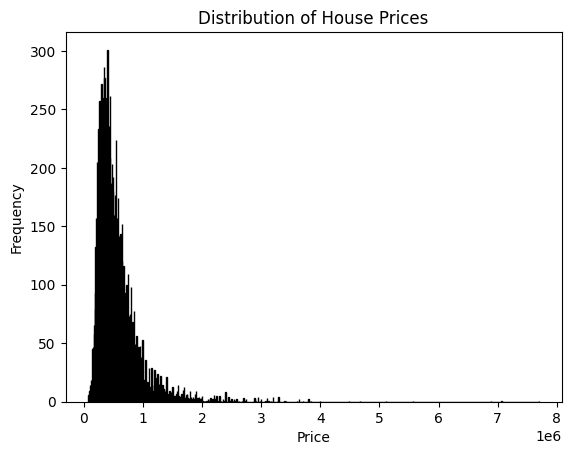

In [16]:
plt.hist(data["Price"], bins=1000, edgecolor='black')
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [17]:
print("Mean:", data["Price"].mean())
print("Median:", data["Price"].median())
print("Skewness:", data["Price"].skew())

Mean: 538806.2816882139
Median: 450000.0
Skewness: 4.272575526089628


<!-- <div dir="rtl" style="text-align: right;">
برای بررسی نوع توزیع،‌ابتدا مشابه مثال قبلی نمودار هیستوگرام را رسم کردیم؛ سپس مقادیر مهم چولگی، میانه و میانگین را برای داده‌های قیمت به دست آوردیم.  
</div> -->
To examine the type of distribution, we first plotted the histogram similar to the previous example; then we calculated important statistics such as skewness, median, and mean for the price data.
Since the mean value is significantly greater than the median, the distribution is right-skewed. Also, because the skewness value is positive, the same conclusion can be drawn. This is also evident from the histogram.


#### 2.7

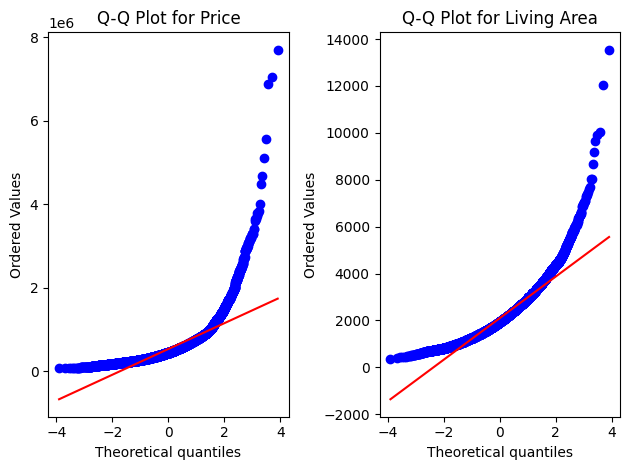

In [18]:
plt.subplot(1,2,1)
stats.probplot(data["Price"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Price")

plt.subplot(1,2,2)
stats.probplot(data['living area'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Living Area")

plt.tight_layout()
plt.show()

<!-- <div dir="rtl" style="text-align: right;">
برای رسم نمودار Q-Q برای این دو ‌ویژگی، با استفاده از stats.probplot نمودار Q-Q Plot  را نسبت به توزیع نرمال رسم کردیم. در این نوع نمودار         نقاط داده را در مقابل مقادیر نظری توزیع نرمال مشاهده می‌کنیم. 
</div> -->
To plot the Q-Q plot for these two features, we used `stats.probplot` to draw the Q-Q Plot relative to the normal distribution. In this type of plot, the data points are compared with the theoretical values of a normal distribution.


#### 2.8

<!-- <div dir="rtl" style="text-align: right;">معیار لوکس بودن خانه را قیمت آن تعریف می‌کنیم و اگر قیمت آن بیشتر
از 
    1000000
    بود آن را به عنوان خانه لوکس در نظر می‌گیریم.
مقدار 1000000 با توجه به نمودار هیستوگرام قیمت ها، انتخاب شده است تا تعداد کمی خانه انتخاب شود.    
</div> -->
We define the luxury criterion of a house based on its price. If the price is greater than 1,000,000, it is considered a luxury house.

The threshold value of 1,000,000 was chosen based on the price histogram so that only a small number of houses are classified as luxury.


In [19]:
number_of_luxury_houses =(data["Price"]>1000000).sum()
print('Number of luxury houses is: ',number_of_luxury_houses)
print('Total number of houses is: ',len(data["Price"]))

Number of luxury houses is:  978
Total number of houses is:  14619


 <!-- <div dir="rtl" style="text-align: right;"> 
حدود ۹۷۸ خانه یعنی 6.689 درصد از کل خانه ها به عنوان خانه لوکس در نظر گرفته می‌شود.     
</div> -->
Approximately 978 houses, which is 6.689% of all houses, are considered luxury houses.


In [20]:
luxury_homes = data[data["Price"] > 1000000]
ordinary_homes= data[data["Price"] <= 1000000]
categorical_features = ['number of bedrooms', 'number of bathrooms', 'living area',
       'lot area', 'number of floors', 'waterfront present',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'living_area_renov', 'lot_area_renov']

for col in categorical_features:
    print(f"Value counts for {col}:")
    print("Luxury homes:", luxury_homes[col].value_counts())
    print("ordinary homes:", ordinary_homes[col].value_counts())
    print(f"Min for {col} (luxury): {luxury_homes[col].min()}")
    print(f"Max for {col} (luxury): {luxury_homes[col].max()}")
    print(f"Min for {col} (ordinary): {ordinary_homes[col].min()}")
    print(f"Max for {col} (ordinary): {ordinary_homes[col].max()}")
    print("\n" + "="*50 + "\n")

Value counts for number of bedrooms:
Luxury homes: number of bedrooms
4     507
5     208
3     191
6      36
2      23
7       7
8       4
9       1
10      1
Name: count, dtype: int64
ordinary homes: number of bedrooms
3     6421
4     4217
2     1821
5      870
6      140
1      136
7       23
8        7
9        2
10       2
33       1
11       1
Name: count, dtype: int64
Min for number of bedrooms (luxury): 2
Max for number of bedrooms (luxury): 10
Min for number of bedrooms (ordinary): 1
Max for number of bedrooms (ordinary): 33


Value counts for number of bathrooms:
Luxury homes: number of bathrooms
2.50    168
3.50    158
3.25    142
2.75     75
3.00     73
2.25     72
3.75     55
4.50     40
4.25     39
4.00     38
1.75     28
2.00     21
4.75     15
5.00     11
5.25     10
1.50     10
5.50      7
1.00      4
6.00      3
8.00      2
6.25      2
6.50      1
6.75      1
5.75      1
7.75      1
1.25      1
Name: count, dtype: int64
ordinary homes: number of bathrooms
2.50    350

 <!-- <div dir="rtl" style="text-align: right;"> 
در اینجا، یک سری از ویژگی‌ها انتخاب شده است و برای هر کدام، بین خانه‌های معمولی و لوکس، پارامترهایی مانند بیشترین مقدار یا کمترین مقدار آن ویژگی‌ها محاسبه شده است. همچنین فراوانی داده‌ها برای هر کدام با value_counts حساب شده است.
 </div> -->

  <!-- <div dir="rtl" style="text-align: right;"> 
با توجه به نتایج می‌توان فهمید که، بیشتر خانه های لوکس حداقل بیشتر از ۴ اتاق خواب دارند و living area بیشتر از ۱۴۴۰ می‌باشد و مقدار lot area  بیشتر از ۱۸۸۰ می‌باشد
 </div> -->

  <!-- <div dir="rtl" style="text-align: right;"> 
همچنین، وضعیت تقریبا همه خانه‌ها مقداری بالای ۳ دارد و تقریبا امتیازی بالا ۸ دارند. 
 </div> -->

Here, a set of features is selected, and for each one, parameters such as the maximum or minimum values are calculated for both regular and luxury houses. Additionally, the frequency of the data for each feature is computed using `value_counts`.

Based on the results, we can observe that most luxury houses have at least 4 bedrooms, a living area greater than 1440, and a lot area greater than 1880.

Also, the condition of almost all houses is above 3, and their grade is approximately higher than 8.




/tmp/ipykernel_6442/2475892841.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  year_stats = df.groupby('Year_bin').agg({'Built Year': 'count', 'Price': 'mean'}).rename(columns={'Built Year': 'Number_of_Houses', 'Price': 'Average_Price'})


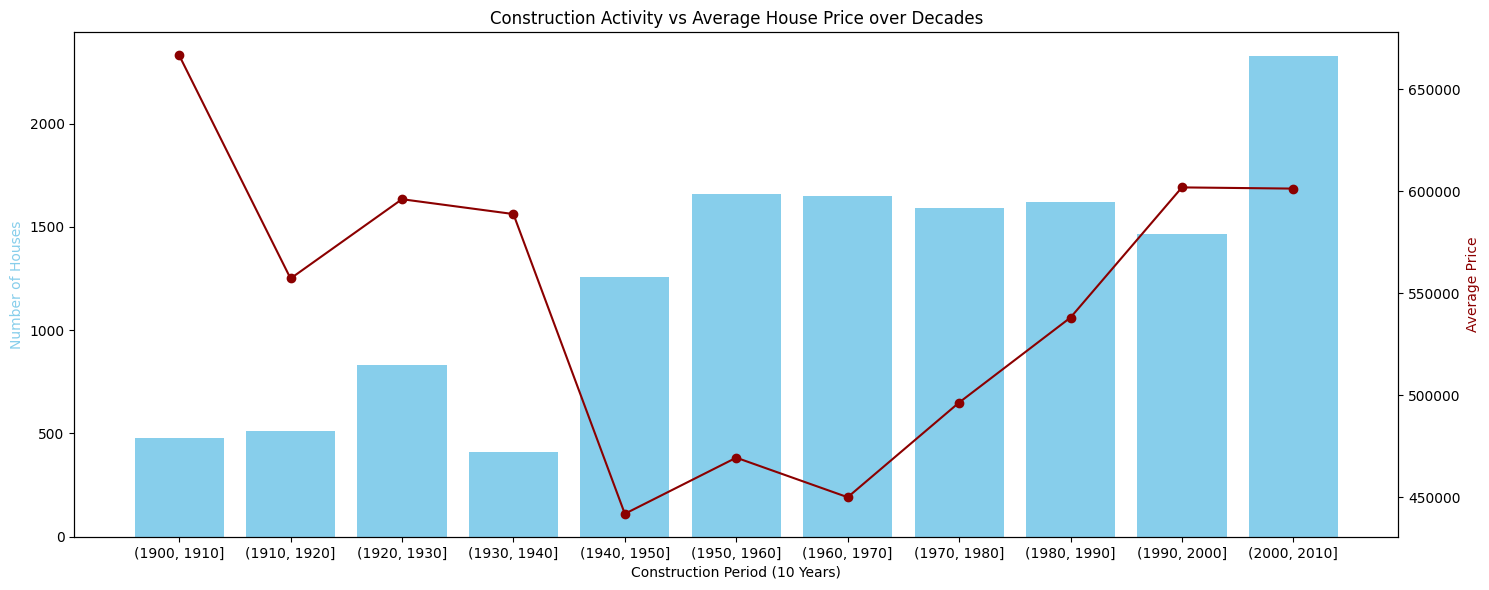

In [ ]:
# this part of code is for responding to question 3.5
df['Year_bin'] = pd.cut(df['Built Year'], bins=range(1900, 2015, 10))
year_stats = df.groupby('Year_bin').agg({'Built Year': 'count', 'Price': 'mean'}).rename(columns={'Built Year': 'Number_of_Houses', 'Price': 'Average_Price'})


fig, ax1 = plt.subplots(figsize=(15,6))

ax1.bar(year_stats.index.astype(str), year_stats['Number_of_Houses'], color='skyblue', label='Number of Houses')
ax1.set_xlabel('Construction Period (10 Years)')
ax1.set_ylabel('Number of Houses', color='skyblue')

ax2 = ax1.twinx()
ax2.plot(year_stats.index.astype(str), year_stats['Average_Price'], color='darkred', marker='o', label='Average Price')
ax2.set_ylabel('Average Price', color='darkred')

plt.title('Construction Activity vs Average House Price over Decades')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### end

---
**End.** Before submitting: **Kernel → Restart & Run All** and save the notebook with all outputs.